[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/powerzoojax/PowerZooPy/blob/main/docs/en/examples/notebooks/nb02_atomic_explorer.ipynb)

# Atomic Explorer

> **Prerequisites**: [NB01 - Quickstart](./nb01_quickstart.ipynb)  ·  **Time**: ~15 minutes

Atomic tasks are small validation presets under `powerzoo.tasks.atomic`.

This notebook is organized from the cleanest single-resource cases to grid-only wrappers. Each section stays deliberately small: `reset` -> one explicit `step` -> short rollout.

For the underlying power-system concepts, use the [Power Systems Primer for ML Researchers](../../guide/power_for_ml.md) as the background reference.


## Contents

- [1. Setup](#1-setup)
- [2. Storage and Mobility Atoms](#2-storage-and-mobility-atoms)
  - [2.1 Battery](#21-battery)
  - [2.2 Vehicle](#22-vehicle)
- [3. Profile-Driven Renewable Atoms](#3-profile-driven-renewable-atoms)
  - [3.1 Solar](#31-solar)
  - [3.2 Wind](#32-wind)
- [4. Flexible Demand and Compute Atoms](#4-flexible-demand-and-compute-atoms)
  - [4.1 FlexLoad](#41-flexload)
  - [4.2 Datacenter](#42-datacenter)
- [5. Grid-Only Atoms](#5-grid-only-atoms)
  - [5.1 Transmission Grid](#51-transmission-grid)
  - [5.2 Distribution Grid](#52-distribution-grid)
- [6. Next Steps](#6-next-steps)


## 1. Setup

The pattern throughout is the same: inspect the initial state, take one explicit step, then run a short rollout to see which fields actually move.


In [1]:
import io
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import powerzoo
from powerzoo.tasks.atomic import make_atomic_task_env

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


/path/to/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-26 22:49:39,435	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-26 22:49:40,753	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## 2. Storage and Mobility Atoms

### 2.1 Battery

Start here. This is the cleanest storage case for reading SOC clipping and realized power.

Background: [Battery Storage and SOC Dynamics](../../guide/power_for_ml.md#31-battery-storage-and-soc-dynamics).

Action is commanded grid-side power `u_t`; the env clips it to a feasible `p_t = current_p_mw` from SOC and power limits. Here `\Delta t = 1\,\mathrm{h}`.

$$\mathrm{soc}_t = E_t / E_{\max}$$
$$E_{t+1}=E_t-\Delta t\,p_t/\eta_d\quad (p_t>0,\ \mathrm{discharge})$$
$$E_{t+1}=E_t-\Delta t\,p_t\,\eta_c\quad (p_t<0,\ \mathrm{charge})$$

Watch `soc`, `energy_stored_mwh`, and realized `current_p_mw`.


In [9]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_battery")
    obs, info = env.reset(seed=0)

battery_id = next(iter(info["resource_status"]))
battery_status = info["resource_status"][battery_id]

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_battery",
                "resource_id": battery_id,
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "soc": battery_status["soc"],
                "energy_stored_mwh": battery_status["energy_stored_mwh"],
                "current_p_mw": battery_status["current_p_mw"],
            }
        ]
    ).round(4)
)


,task,resource_id,action_space,obs_dim,episode_step,soc,energy_stored_mwh,current_p_mw
0,atomic_battery,battery_0,"Box(-0.2, 0.2, (1,), float32)",108,0,0.5,0.25,0.0


In [10]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_battery")
    obs_before, info_before = env.reset(seed=0)
    battery_id = next(iter(info_before["resource_status"]))
    before = info_before["resource_status"][battery_id]

    action = np.array([0.2], dtype=np.float32)
    obs_after, reward, terminated, truncated, info_after = env.step(action)
    after = info_after["resource_status"][battery_id]

display(
    pd.DataFrame(
        [
            {
                "stage": "before step",
                "command": "reset",
                "episode_step": info_before["episode_step"],
                "soc": before["soc"],
                "energy_stored_mwh": before["energy_stored_mwh"],
                "current_p_mw": before["current_p_mw"],
            },
            {
                "stage": "after one step",
                "command": "+0.2 MW",
                "episode_step": info_after["episode_step"],
                "soc": after["soc"],
                "energy_stored_mwh": after["energy_stored_mwh"],
                "current_p_mw": after["current_p_mw"],
            },
        ]
    ).round(4)
)


,stage,command,episode_step,soc,energy_stored_mwh,current_p_mw
0,before step,reset,0,0.5,0.25,0.0000
1,after one step,+0.2 MW,1,0.1,0.05,0.1949


,step,action_mw,soc,energy_stored_mwh,current_p_mw
0,1,0.2,0.1000,0.0500,0.1949
1,2,-0.2,0.4899,0.2449,-0.2000
2,3,0.1,0.2847,0.1423,0.1000
3,4,-0.1,0.4796,0.2398,-0.1000
4,5,0.0,0.4796,0.2398,0.0000


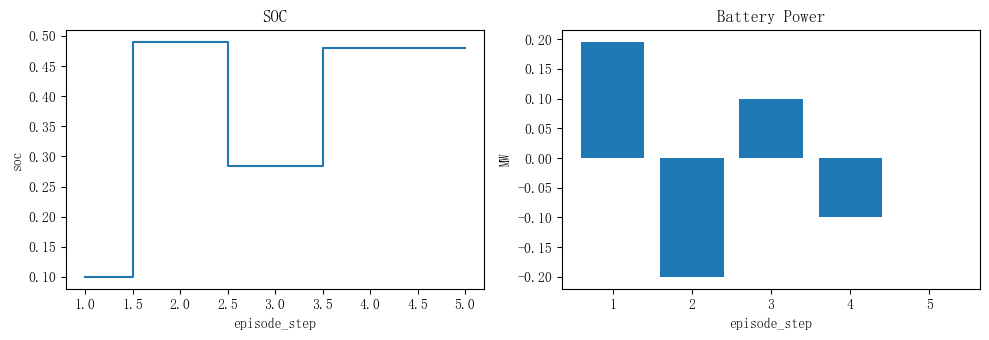

In [11]:
battery_actions = [0.2, -0.2, 0.1, -0.1, 0.0]

with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_battery")
    obs, info = env.reset(seed=0)
    battery_id = next(iter(info["resource_status"]))
    rows = []

    for value in battery_actions:
        action = np.array([value], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        status = info["resource_status"][battery_id]
        rows.append(
            {
                "step": info["episode_step"],
                "action_mw": value,
                "soc": status["soc"],
                "energy_stored_mwh": status["energy_stored_mwh"],
                "current_p_mw": status["current_p_mw"],
            }
        )

battery_df = pd.DataFrame(rows)
display(battery_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].step(battery_df["step"], battery_df["soc"], where="mid")
axes[0].set_title("SOC")
axes[0].set_xlabel("episode_step")
axes[0].set_ylabel("soc")
axes[1].bar(battery_df["step"], battery_df["current_p_mw"])
axes[1].set_title("Battery Power")
axes[1].set_xlabel("episode_step")
axes[1].set_ylabel("MW")
plt.tight_layout()
plt.show()


### 2.2 Vehicle

This is the cleanest mobility case: battery dynamics plus availability windows and a departure requirement.

Background: [Battery Storage and SOC Dynamics](../../guide/power_for_ml.md#31-battery-storage-and-soc-dynamics) and [Electric Vehicles (G2V / V2G)](../../guide/power_for_ml.md#32-electric-vehicles-g2v-v2g).

Departure and arrival are processed before the action each step. On a departure step the trip energy is deducted first; on arrival the EV becomes controllable again.

$$p_t=0\quad\text{when }\texttt{is\_home}=0$$
$$\mathrm{departure\_ready}=\mathbb{1}[\mathrm{soc}_t \ge \mathrm{soc}_{\min}^{\mathrm{dep}}]$$

Watch `soc`, `is_home`, and `departure_ready`.


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_vehicle")
    obs, info = env.reset(seed=0)

vehicle_id = next(iter(info["resource_status"]))
vehicle_status = info["resource_status"][vehicle_id]

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_vehicle",
                "resource_id": vehicle_id,
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "soc": vehicle_status["soc"],
                "is_home": vehicle_status["is_home"],
                "departure_ready": vehicle_status["departure_ready"],
                "time_of_day": vehicle_status["time_of_day"],
            }
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_vehicle")
    obs_before, info_before = env.reset(seed=0)
    vehicle_id = next(iter(info_before["resource_status"]))
    before = info_before["resource_status"][vehicle_id]

    action = np.array([-0.007], dtype=np.float32)
    obs_after, reward, terminated, truncated, info_after = env.step(action)
    after = info_after["resource_status"][vehicle_id]

display(
    pd.DataFrame(
        [
            {
                "stage": "before step",
                "action": "reset",
                "episode_step": info_before["episode_step"],
                "time_of_day": before["time_of_day"],
                "soc": before["soc"],
                "is_home": before["is_home"],
                "departure_ready": before["departure_ready"],
                "current_p_mw": before["current_p_mw"],
            },
            {
                "stage": "after one step",
                "action": "-0.007 MW",
                "episode_step": info_after["episode_step"],
                "time_of_day": after["time_of_day"],
                "soc": after["soc"],
                "is_home": after["is_home"],
                "departure_ready": after["departure_ready"],
                "current_p_mw": after["current_p_mw"],
            },
        ]
    ).round(4)
)


In [ ]:
vehicle_actions = [-0.007] * 4 + [0.0] * 16

with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_vehicle")
    obs, info = env.reset(seed=0)
    vehicle_id = next(iter(info["resource_status"]))
    rows = []

    for value in vehicle_actions:
        action = np.array([value], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        status = info["resource_status"][vehicle_id]
        rows.append(
            {
                "step": info["episode_step"],
                "action_mw": value,
                "time_of_day": status["time_of_day"],
                "soc": status["soc"],
                "is_home": status["is_home"],
                "departure_ready": status["departure_ready"],
                "current_p_mw": status["current_p_mw"],
            }
        )

vehicle_df = pd.DataFrame(rows)
display(vehicle_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(vehicle_df["step"], vehicle_df["soc"], marker="o")
axes[0].set_title("Vehicle SOC")
axes[0].set_xlabel("episode_step")
axes[0].set_ylabel("soc")
axes[1].step(vehicle_df["step"], vehicle_df["is_home"].astype(int), where="mid")
axes[1].set_title("Home Availability")
axes[1].set_xlabel("episode_step")
axes[1].set_ylabel("is_home")
plt.tight_layout()
plt.show()


## 3. Profile-Driven Renewable Atoms

### 3.1 Solar

Background: [Time-Series Data and Non-Stationarity](../../guide/power_for_ml.md#42-time-series-data-and-non-stationarity).

Resource-level curtailment action. This does not mean the stable public benchmark surface exposes solar control by default.

Reset starts at midnight, so the first case warms into daylight.

$$p_t=(1-c_t)\,\alpha_t\,P_{\max}$$
$$\mathrm{profile\_value}_t = p_t / P_{\max}$$

Watch `profile_value` as the realized output fraction after curtailment, and `current_p_mw`.


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_solar")
    obs, info = env.reset(seed=0)

solar_id = next(iter(info["resource_status"]))
solar_status = info["resource_status"][solar_id]

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_solar",
                "resource_id": solar_id,
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "profile_value": solar_status["profile_value"],
                "current_p_mw": solar_status["current_p_mw"],
                "note": "reset starts before solar production ramps up",
            }
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_solar")
    obs, info = env.reset(seed=0)
    solar_id = next(iter(info["resource_status"]))

    for _ in range(24):
        obs, reward, terminated, truncated, info = env.step(np.array([0.0], dtype=np.float32))
    before = info["resource_status"][solar_id]

    action = np.array([0.6], dtype=np.float32)
    obs, reward, terminated, truncated, info = env.step(action)
    after = info["resource_status"][solar_id]

display(
    pd.DataFrame(
        [
            {
                "stage": "after daylight warm-up",
                "curtailment": 0.0,
                "time_step": before["time_step"],
                "realized_output_frac": before["profile_value"],
                "current_p_mw": before["current_p_mw"],
            },
            {
                "stage": "after one more step",
                "curtailment": 0.6,
                "time_step": after["time_step"],
                "realized_output_frac": after["profile_value"],
                "current_p_mw": after["current_p_mw"],
            },
        ]
    ).round(4)
)


In [ ]:
solar_actions = [0.0, 0.25, 0.5, 0.75, 1.0]
rows = []

with redirect_stdout(io.StringIO()):
    for value in solar_actions:
        env = make_atomic_task_env("atomic_solar")
        obs, info = env.reset(seed=0)
        solar_id = next(iter(info["resource_status"]))

        for _ in range(24):
            obs, reward, terminated, truncated, info = env.step(np.array([0.0], dtype=np.float32))

        obs, reward, terminated, truncated, info = env.step(np.array([value], dtype=np.float32))
        status = info["resource_status"][solar_id]
        rows.append(
            {
                "curtailment": value,
                "time_step": status["time_step"],
                "realized_output_frac": status["profile_value"],
                "current_p_mw": status["current_p_mw"],
            }
        )

solar_df = pd.DataFrame(rows)
display(solar_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(solar_df["curtailment"], solar_df["realized_output_frac"], marker="o")
axes[0].set_title("Same Daylight Step")
axes[0].set_xlabel("curtailment")
axes[0].set_ylabel("realized_output_frac")
axes[1].bar(solar_df["curtailment"].astype(str), solar_df["current_p_mw"])
axes[1].set_title("Realized Solar Output")
axes[1].set_xlabel("curtailment")
axes[1].set_ylabel("MW")
plt.tight_layout()
plt.show()


### 3.2 Wind

Background: [Time-Series Data and Non-Stationarity](../../guide/power_for_ml.md#42-time-series-data-and-non-stationarity).

Resource-level curtailment action. This does not mean the stable public benchmark surface exposes wind control by default.

At reset, `current_p_mw = 0`. Output appears after the first step.

$$p_t=(1-c_t)\,\alpha_t\,P_{\max}$$
$$\mathrm{profile\_value}_t = p_t / P_{\max}$$

Watch `profile_value` as the realized output fraction after curtailment, and `current_p_mw`.


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_wind")
    obs, info = env.reset(seed=0)

wind_id = next(iter(info["resource_status"]))
wind_status = info["resource_status"][wind_id]

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_wind",
                "resource_id": wind_id,
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "profile_value": wind_status["profile_value"],
                "current_p_mw": wind_status["current_p_mw"],
            }
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_wind")
    obs_before, info_before = env.reset(seed=0)
    wind_id = next(iter(info_before["resource_status"]))
    before = info_before["resource_status"][wind_id]

    action = np.array([0.5], dtype=np.float32)
    obs_after, reward, terminated, truncated, info_after = env.step(action)
    after = info_after["resource_status"][wind_id]

display(
    pd.DataFrame(
        [
            {
                "stage": "at reset",
                "curtailment": "reset",
                "time_step": before["time_step"],
                "realized_output_frac": before["profile_value"],
                "current_p_mw": before["current_p_mw"],
            },
            {
                "stage": "after first step",
                "curtailment": 0.5,
                "time_step": after["time_step"],
                "realized_output_frac": after["profile_value"],
                "current_p_mw": after["current_p_mw"],
            },
        ]
    ).round(4)
)


In [ ]:
wind_actions = [0.0, 0.25, 0.5, 0.75, 1.0]
rows = []

with redirect_stdout(io.StringIO()):
    for value in wind_actions:
        env = make_atomic_task_env("atomic_wind")
        obs, info = env.reset(seed=0)
        wind_id = next(iter(info["resource_status"]))

        obs, reward, terminated, truncated, info = env.step(np.array([value], dtype=np.float32))
        status = info["resource_status"][wind_id]
        rows.append(
            {
                "curtailment": value,
                "time_step": status["time_step"],
                "realized_output_frac": status["profile_value"],
                "current_p_mw": status["current_p_mw"],
            }
        )

wind_df = pd.DataFrame(rows)
display(wind_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(wind_df["curtailment"], wind_df["realized_output_frac"], marker="o")
axes[0].set_title("Same First Step")
axes[0].set_xlabel("curtailment")
axes[0].set_ylabel("realized_output_frac")
axes[1].bar(wind_df["curtailment"].astype(str), wind_df["current_p_mw"])
axes[1].set_title("Realized Wind Output")
axes[1].set_xlabel("curtailment")
axes[1].set_ylabel("MW")
plt.tight_layout()
plt.show()


## 4. Flexible Demand and Compute Atoms

### 4.1 FlexLoad

One scalar action, but with memory.

$$p_t = \text{released}_t - \text{shifted}_t + \text{curtailed}_t$$
$$B_{t+1}=B_t+\text{shifted}_t-\text{released}_t$$

Here `buffer_total_mw` is the remaining sum of scheduled future releases, not an energy state.

Watch `current_p_mw`, `shifted_mw`, and `buffer_total_mw`.


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_flexload")
    obs, info = env.reset(seed=0)

flex_id = next(iter(info["resource_status"]))
flex_status = info["resource_status"][flex_id]

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_flexload",
                "resource_id": flex_id,
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "current_p_mw": flex_status["current_p_mw"],
                "shifted_mw": flex_status["shifted_mw"],
                "buffer_total_mw": flex_status["buffer_total_mw"],
            }
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_flexload")
    obs_before, info_before = env.reset(seed=0)
    flex_id = next(iter(info_before["resource_status"]))
    before = info_before["resource_status"][flex_id]

    action = np.array([-4.0], dtype=np.float32)
    obs_after, reward, terminated, truncated, info_after = env.step(action)
    after = info_after["resource_status"][flex_id]

display(
    pd.DataFrame(
        [
            {
                "stage": "before step",
                "action": "reset",
                "episode_step": info_before["episode_step"],
                "current_p_mw": before["current_p_mw"],
                "shifted_mw": before["shifted_mw"],
                "buffer_total_mw": before["buffer_total_mw"],
            },
            {
                "stage": "after one step",
                "action": "-4.0 MW",
                "episode_step": info_after["episode_step"],
                "current_p_mw": after["current_p_mw"],
                "shifted_mw": after["shifted_mw"],
                "buffer_total_mw": after["buffer_total_mw"],
            },
        ]
    ).round(4)
)


In [ ]:
flex_actions = [-4.0, 0.0, 0.0, 0.0, 0.0, 2.0]

with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_flexload")
    obs, info = env.reset(seed=0)
    flex_id = next(iter(info["resource_status"]))
    rows = []

    for value in flex_actions:
        action = np.array([value], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        status = info["resource_status"][flex_id]
        rows.append(
            {
                "step": info["episode_step"],
                "action_mw": value,
                "current_p_mw": status["current_p_mw"],
                "curtailed_mw": status["curtailed_mw"],
                "shifted_mw": status["shifted_mw"],
                "buffer_total_mw": status["buffer_total_mw"],
            }
        )

flex_df = pd.DataFrame(rows)
display(flex_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(flex_df["step"], flex_df["current_p_mw"])
axes[0].set_title("Net Grid Impact")
axes[0].set_xlabel("episode_step")
axes[0].set_ylabel("MW")
axes[1].plot(flex_df["step"], flex_df["buffer_total_mw"], marker="o")
axes[1].set_title("Deferred Buffer")
axes[1].set_xlabel("episode_step")
axes[1].set_ylabel("MW")
plt.tight_layout()
plt.show()


### 4.2 Datacenter

Three controls: `[r_train, r_finetune, cooling_setpoint]`.

`r_train` allocates a fraction of currently available GPUs to queued training jobs. `r_finetune` allocates a fraction of the remaining GPUs to queued finetuning jobs. `cooling_setpoint` maps from `[0, 1]` to `[18, 27]` degC. Urgent queued jobs can also be auto-scheduled before the RL-controlled allocation.

$$p_{dc,t}=p_{it,t}+p_{cool,t}+p_{aux,t},\qquad p_{aux,t}=f_{aux}\,p_{it,t}$$
$$\mathrm{PUE}_t = p_{dc,t} / p_{it,t} = 1 + 1/\mathrm{COP}_t + f_{aux}$$

`cooling_setpoint` moves `t_setpoint`, not `p_cool_mw` directly; `t_zone` responds through thermal dynamics.

Watch `p_dc_mw`, `pue`, `t_zone`, `t_setpoint`, and `gpus_active`.


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_datacenter")
    obs, info = env.reset(seed=0)

resource_id = next(iter(info["resource_status"]))
status = info["resource_status"][resource_id]

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_datacenter",
                "resource_id": resource_id,
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "p_dc_mw": status["p_dc_mw"],
                "pue": status["pue"],
                "t_zone": status["t_zone"],
                "t_setpoint": status["t_setpoint"],
                "gpus_active": status["gpus_active"],
                "n_running": status["n_running"],
            }
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_datacenter")
    obs_before, info_before = env.reset(seed=0)
    resource_id = next(iter(info_before["resource_status"]))
    before = info_before["resource_status"][resource_id]

    action = np.array([0.8, 0.2, 0.2], dtype=np.float32)
    obs_after, reward, terminated, truncated, info_after = env.step(action)
    after = info_after["resource_status"][resource_id]

display(
    pd.DataFrame(
        [
            {
                "stage": "before step",
                "action": "reset",
                "episode_step": info_before["episode_step"],
                "p_dc_mw": before["p_dc_mw"],
                "pue": before["pue"],
                "t_zone": before["t_zone"],
                "t_setpoint": before["t_setpoint"],
                "gpus_active": before["gpus_active"],
                "n_running": before["n_running"],
            },
            {
                "stage": "after first transition",
                "action": "[0.8, 0.2, 0.2]",
                "episode_step": info_after["episode_step"],
                "p_dc_mw": after["p_dc_mw"],
                "pue": after["pue"],
                "t_zone": after["t_zone"],
                "t_setpoint": after["t_setpoint"],
                "gpus_active": after["gpus_active"],
                "n_running": after["n_running"],
            },
        ]
    ).round(4)
)


In [ ]:
datacenter_actions = [
    np.array([0.0, 0.0, 1.0], dtype=np.float32),
    np.array([0.0, 0.0, 1.0], dtype=np.float32),
    np.array([0.8, 0.2, 0.2], dtype=np.float32),
    np.array([0.8, 0.2, 0.2], dtype=np.float32),
    np.array([0.3, 0.8, 0.8], dtype=np.float32),
    np.array([0.3, 0.8, 0.8], dtype=np.float32),
]

with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_datacenter")
    obs, info = env.reset(seed=0)
    resource_id = next(iter(info["resource_status"]))
    rows = []

    for value in datacenter_actions:
        obs, reward, terminated, truncated, info = env.step(value)
        status = info["resource_status"][resource_id]
        rows.append(
            {
                "step": info["episode_step"],
                "action": value.tolist(),
                "gpus_active": status["gpus_active"],
                "n_running": status["n_running"],
                "p_it_mw": status["p_it_mw"],
                "p_cool_mw": status["p_cool_mw"],
                "p_dc_mw": status["p_dc_mw"],
                "pue": status["pue"],
                "t_zone": status["t_zone"],
                "t_setpoint": status["t_setpoint"],
            }
        )

datacenter_df = pd.DataFrame(rows)
display(datacenter_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(datacenter_df["step"], datacenter_df["p_dc_mw"], marker="o")
axes[0].set_title("Total DC Power")
axes[0].set_xlabel("episode_step")
axes[0].set_ylabel("MW")
axes[1].plot(datacenter_df["step"], datacenter_df["t_zone"], marker="o")
axes[1].plot(datacenter_df["step"], datacenter_df["t_setpoint"], marker="o", linestyle="--")
axes[1].set_title("Thermal State")
axes[1].set_xlabel("episode_step")
axes[1].set_ylabel("degC")
axes[1].legend(["t_zone", "t_setpoint"])
plt.tight_layout()
plt.show()


## 5. Grid-Only Atoms

### 5.1 Transmission Grid

Background: [Network and Physics](../../guide/power_for_ml.md#1-network-and-physics), [Optimal Power Flow (OPF)](../../guide/power_for_ml.md#21-optimal-power-flow-opf), and [Voltage and Thermal Limits](../../guide/power_for_ml.md#41-voltage-and-thermal-limits-safety-constraints).

No action is exposed in this atomic wrapper. `PowerEnv` can expose grid actions, but `FlattenWrapper` only flattens resource actions here, so the action space is empty and grid redispatch is automatic.

$$(\sin\phi_t,\cos\phi_t),\qquad \phi_t = 2\pi t / T$$

Watch `total_generation_mw`, `opf_cost`, and `episode_step`.


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_transmission_grid")
    obs, info = env.reset(seed=0)

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_transmission_grid",
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "total_generation_mw": info["total_generation_mw"],
                "opf_cost": info["opf_cost"],
                "cost_sum": info["cost_sum"],
                "is_safe": info["is_safe"],
            }
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_transmission_grid")
    obs_before, info_before = env.reset(seed=0)

    noop_action = env.action_space.sample()
    obs_after, reward, terminated, truncated, info_after = env.step(noop_action)

display(
    pd.DataFrame(
        [
            {
                "stage": "before step",
                "action": "reset",
                "episode_step": info_before["episode_step"],
                "total_generation_mw": info_before["total_generation_mw"],
                "opf_cost": info_before["opf_cost"],
                "cost_sum": info_before["cost_sum"],
            },
            {
                "stage": "after one step",
                "action": list(noop_action),
                "episode_step": info_after["episode_step"],
                "total_generation_mw": info_after["total_generation_mw"],
                "opf_cost": info_after["opf_cost"],
                "cost_sum": info_after["cost_sum"],
            },
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_transmission_grid")
    obs, info = env.reset(seed=0)
    rows = [
        {
            "step": info["episode_step"],
            "total_generation_mw": info["total_generation_mw"],
            "opf_cost": info["opf_cost"],
            "obs0": float(obs[0]),
            "time_sin": float(obs[-2]),
            "time_cos": float(obs[-1]),
        }
    ]

    for _ in range(6):
        noop_action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(noop_action)
        rows.append(
            {
                "step": info["episode_step"],
                "total_generation_mw": info["total_generation_mw"],
                "opf_cost": info["opf_cost"],
                "obs0": float(obs[0]),
                "time_sin": float(obs[-2]),
                "time_cos": float(obs[-1]),
            }
        )

transmission_df = pd.DataFrame(rows)
display(transmission_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(transmission_df["step"], transmission_df["total_generation_mw"], marker="o")
axes[0].set_title("Total Generation")
axes[0].set_xlabel("episode_step")
axes[0].set_ylabel("MW")
axes[1].plot(transmission_df["step"], transmission_df["opf_cost"], marker="o")
axes[1].set_title("OPF Cost")
axes[1].set_xlabel("episode_step")
axes[1].set_ylabel("cost")
plt.tight_layout()
plt.show()


### 5.2 Distribution Grid

Background: [Power Flow](../../guide/power_for_ml.md#12-power-flow-the-physics-engine), [Distribution vs Transmission](../../guide/power_for_ml.md#distribution-vs-transmission), and [Voltage and Thermal Limits](../../guide/power_for_ml.md#41-voltage-and-thermal-limits-safety-constraints).

Same empty action space. In the current grid-only setup, `episode_step` and time features move but losses are nearly flat, so this section is mainly a step-contract check.

$$(\sin\phi_t,\cos\phi_t),\qquad \phi_t = 2\pi t / T$$

Watch `p_loss_MW`, `episode_step`, and the time features at the tail of the observation.


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_distribution_grid")
    obs, info = env.reset(seed=0)

display(
    pd.DataFrame(
        [
            {
                "task": "atomic_distribution_grid",
                "action_space": str(env.action_space),
                "obs_dim": obs.shape[0],
                "episode_step": info["episode_step"],
                "p_loss_MW": info["p_loss_MW"],
                "q_loss_MVAr": info["q_loss_MVAr"],
                "cost_sum": info["cost_sum"],
                "is_safe": info["is_safe"],
            }
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_distribution_grid")
    obs_before, info_before = env.reset(seed=0)

    noop_action = env.action_space.sample()
    obs_after, reward, terminated, truncated, info_after = env.step(noop_action)

display(
    pd.DataFrame(
        [
            {
                "stage": "before step",
                "action": "reset",
                "episode_step": info_before["episode_step"],
                "p_loss_MW": info_before["p_loss_MW"],
                "q_loss_MVAr": info_before["q_loss_MVAr"],
                "time_sin": float(obs_before[-2]),
                "time_cos": float(obs_before[-1]),
            },
            {
                "stage": "after one step",
                "action": list(noop_action),
                "episode_step": info_after["episode_step"],
                "p_loss_MW": info_after["p_loss_MW"],
                "q_loss_MVAr": info_after["q_loss_MVAr"],
                "time_sin": float(obs_after[-2]),
                "time_cos": float(obs_after[-1]),
            },
        ]
    ).round(4)
)


In [ ]:
with redirect_stdout(io.StringIO()):
    env = make_atomic_task_env("atomic_distribution_grid")
    obs, info = env.reset(seed=0)
    rows = [
        {
            "step": info["episode_step"],
            "p_loss_MW": info["p_loss_MW"],
            "q_loss_MVAr": info["q_loss_MVAr"],
            "time_sin": float(obs[-2]),
            "time_cos": float(obs[-1]),
        }
    ]

    for _ in range(6):
        noop_action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(noop_action)
        rows.append(
            {
                "step": info["episode_step"],
                "p_loss_MW": info["p_loss_MW"],
                "q_loss_MVAr": info["q_loss_MVAr"],
                "time_sin": float(obs[-2]),
                "time_cos": float(obs[-1]),
            }
        )

distribution_df = pd.DataFrame(rows)
display(distribution_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(distribution_df["step"], distribution_df["p_loss_MW"], marker="o")
axes[0].set_title("Active Power Loss")
axes[0].set_xlabel("episode_step")
axes[0].set_ylabel("MW")
axes[1].plot(distribution_df["step"], distribution_df["time_sin"], marker="o")
axes[1].set_title("Observation Clock")
axes[1].set_xlabel("episode_step")
axes[1].set_ylabel("time_sin")
plt.tight_layout()
plt.show()


## 6. Next Steps

- [Power Systems Primer for ML Researchers](../../guide/power_for_ml.md)
- [NB04 - Task 1: OPF](./nb04_task_opf.ipynb)
- [NB05 - Task 2: DER Arbitrage](./nb05_task_der.ipynb)
- [NB06 - Task 3: EV V2G](./nb06_task_ev.ipynb)
